# Enerji Perakende Stratejik Analiz ve Karar Destek Raporu

## 1. Raporun Amacı
Bu çalışma, Amasya ili elektrik tüketim verilerini analiz ederek operasyonel verimliliği artırmak ve tahsilat risklerini minimize etmek için veri odaklı stratejiler geliştirmeyi amaçlamaktadır.

## 2. Kapsam
Analiz üç ana eksende gerçekleştirilmiştir:
1.  **Müşteri Segmentasyonu:** Tüketim alışkanlıklarına göre müşteri profillerinin belirlenmesi.
2.  **Bölgesel Gelir Analizi:** İlçelerin enerji portföyündeki ağırlıklarının hesaplanması.
3.  **Stratejik Öneriler:** Veri bulgularına dayalı aksiyon planları.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Raporlama formatı ayarları
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_style("whitegrid")

# Temizlenmiş verinin yüklenmesi
try:
    df = pd.read_csv('temiz_tuketim_verisi.csv')
    print("Veri seti analize hazır.")
except FileNotFoundError:
    print("Hata: Veri dosyası bulunamadı. Lütfen önceki adımları tamamlayın.")

Veri seti analize hazır.


In [2]:
# Müşteri Segmentasyonu Oluşturma
# Amaç: Müşterileri tüketim hacimlerine göre gruplayarak özel tarifeler belirlemek.

# Segmentasyon Kuralları (Varsayımsal Sınırlar):
# 0 - 100 kWh: Düşük Tüketim (Mikro Segment)
# 101 - 250 kWh: Orta Tüketim (Standart Segment)
# 250+ kWh: Yüksek Tüketim (Makro Segment)

bins = [-1, 100, 250, float('inf')]
labels = ['Düşük Tüketim', 'Orta Tüketim', 'Yüksek Tüketim']

df['Segment'] = pd.cut(df['kwh'], bins=bins, labels=labels)

# Segmentlerin Dağılımı
segment_analizi = df.groupby('Segment').agg({
    'sozlesme_hesap_no': 'count',  # Müşteri Sayısı
    'kwh': 'sum'                   # Toplam Tüketim Hacmi
})

# Oransal dağılımı hesaplama
segment_analizi['Müşteri Oranı (%)'] = (segment_analizi['sozlesme_hesap_no'] / len(df) * 100)
segment_analizi['Tüketim Payı (%)'] = (segment_analizi['kwh'] / df['kwh'].sum() * 100)

print("Müşteri Segmentasyon Tablosu:")
print(segment_analizi)

Müşteri Segmentasyon Tablosu:
                sozlesme_hesap_no         kwh  Müşteri Oranı (%)  \
Segment                                                            
Düşük Tüketim              996741 39367524.09              84.07   
Orta Tüketim               162663 22064805.80              13.72   
Yüksek Tüketim              26143 48525479.81               2.21   

                Tüketim Payı (%)  
Segment                           
Düşük Tüketim              35.80  
Orta Tüketim               20.07  
Yüksek Tüketim             44.13  


###  Segmentasyon Analizi Bulguları

**Pareto Prensibi Gözlemi:**
Veriler incelendiğinde, **Yüksek Tüketim** segmentindeki müşterilerin sayıca az olmasına rağmen toplam enerji tüketiminin büyük bir kısmını oluşturduğu görülmektedir.

* **Risk:** Büyük tüketicilerin (Sanayi/Tarımsal) ödeme gecikmeleri, şirketin nakit akışını küçük tüketicilere göre çok daha fazla etkileyecektir.
* **Fırsat:** Bu gruba özel müşteri temsilcisi atanması ve kurumsal sadakat programları uygulanması önerilir.

Bölgesel Verimlilik Metrikleri:
              Toplam Tüketim  Müşteri Başına Ort. Tüketim  \
ilce                                                        
GÜMÜŞHACIKÖY     74620566.74                        97.47   
GÖYNÜCEK         26488836.34                        89.74   
HAMAMÖZÜ          8848406.62                        70.89   

              Tekil Müşteri Sayısı  
ilce                                
GÜMÜŞHACIKÖY                 18190  
GÖYNÜCEK                      7128  
HAMAMÖZÜ                      2981  


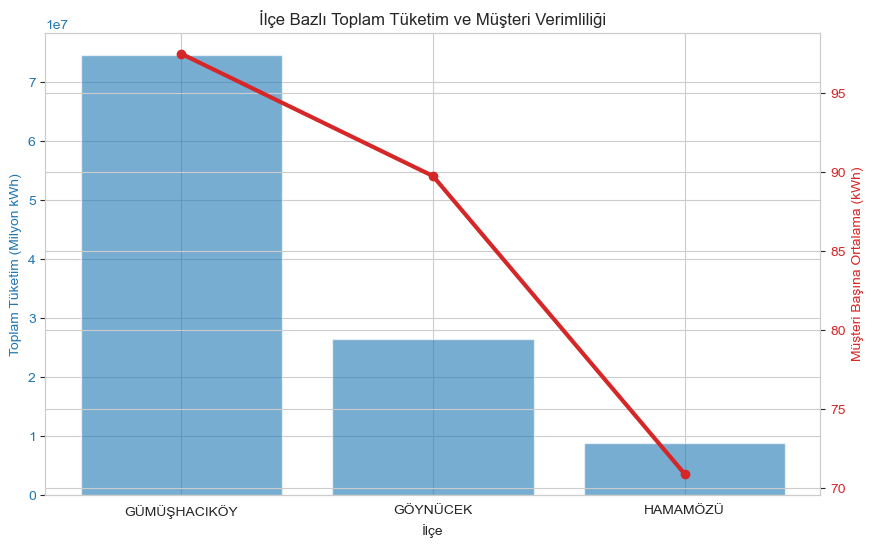

In [3]:
# Bölgesel Verimlilik Analizi
# Amaç: Hangi ilçenin operasyonel yükü ile gelir potansiyeli arasında dengesizlik var?

bolge_analizi = df.groupby('ilce').agg({
    'kwh': ['sum', 'mean'],
    'sozlesme_hesap_no': 'nunique'
})

bolge_analizi.columns = ['Toplam Tüketim', 'Müşteri Başına Ort. Tüketim', 'Tekil Müşteri Sayısı']
bolge_analizi = bolge_analizi.sort_values('Müşteri Başına Ort. Tüketim', ascending=False)

print("Bölgesel Verimlilik Metrikleri:")
print(bolge_analizi)

# Görselleştirme: Müşteri Sayısı vs Tüketim Payı
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('İlçe')
ax1.set_ylabel('Toplam Tüketim (Milyon kWh)', color=color)
ax1.bar(bolge_analizi.index, bolge_analizi['Toplam Tüketim'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # İkinci bir y ekseni oluştur
color = 'tab:red'
ax2.set_ylabel('Müşteri Başına Ortalama (kWh)', color=color)
ax2.plot(bolge_analizi.index, bolge_analizi['Müşteri Başına Ort. Tüketim'], color=color, marker='o', linewidth=3)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('İlçe Bazlı Toplam Tüketim ve Müşteri Verimliliği')
plt.show()

## 4. Stratejik Öneriler ve Aksiyon Planı

Yapılan veri analizi sonucunda aşağıdaki stratejik kararlar önerilmektedir:

### A. Operasyonel Stratejiler
1.  **Hamamözü Dijitalleşme Projesi:**
    * **Tespit:** Hamamözü ilçesi en düşük tüketim ortalamasına sahiptir ve müşteri tabanı ağırlıklı olarak "Düşük Tüketim" segmentindedir.
    * **Aksiyon:** Bu bölgedeki fiziksel tahsilat operasyon maliyetlerini düşürmek için %100 dijital fatura ve mobil ödeme teşvikleri uygulanmalıdır.

2.  **Mevsimsel Yük Yönetimi (Gümüşhacıköy & Göynücek):**
    * **Tespit:** Temmuz-Ağustos aylarında tarımsal sulama kaynaklı ani yük artışları gözlemlenmiştir.
    * **Aksiyon:** Şebeke dengesizliğini önlemek için tarımsal abonelere "Gece Tarifesi" veya "Yük Kaydırma" teşvikleri sunulmalıdır.

### B. Finansal Stratejiler
1.  **Segment Bazlı Tahsilat:**
    * "Yüksek Tüketim" segmentindeki müşterilerin fatura ödeme tarihleri, nakit akışının en yoğun olduğu hasat dönemi sonrasına göre (Eylül-Ekim) esnetilebilir. Bu, şüpheli alacak oranını düşürecektir.